In [ ]:
# @title 1: Install Required Packages
# Install required packages
!pip install rdkit-pypi tqdm seaborn ipywidgets -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.4/29.4 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.1 MB/s eta 0:00:00


In [ ]:
# @title 2: Import Necessary Libraries and plot styles
import os
import io
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import Draw, PandasTools, Descriptors

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams.update({
    'figure.figsize': (12, 8),
    'figure.dpi': 300,
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'DejaVu Sans'
})


In [ ]:
# @title 3: Create output folder
output_dir = Path('/content/filtered_compounds')
output_dir.mkdir(exist_ok=True)


In [ ]:
# @title 4: Upload compound CSV file
print("Please upload your compound file (CSV). It must contain 'compound_name' and 'smiles' columns.")
uploaded = files.upload()

if uploaded:
    compound_file = list(uploaded.keys())[0]
    compounds_data = pd.read_csv(io.BytesIO(uploaded[compound_file]))

    # Normalize columns
    if 'SMILES' in compounds_data.columns and 'smiles' not in compounds_data.columns:
        compounds_data['smiles'] = compounds_data['SMILES']
    if 'compound_name' not in compounds_data.columns:
        if 'name' in compounds_data.columns:
            compounds_data['compound_name'] = compounds_data['name']
        elif 'ID' in compounds_data.columns:
            compounds_data['compound_name'] = compounds_data['ID']
        else:
            compounds_data['compound_name'] = [f"COMP_{i}" for i in range(len(compounds_data))]

    print(f"Loaded compound dataset with {len(compounds_data)} entries.")
else:
    raise ValueError("Compound file upload required to proceed.")


Please upload your compound file (CSV). It must contain 'compound_name' and 'smiles' columns.


Saving BRENK, NIH and PAINS_filtered_compounds.csv to BRENK, NIH and PAINS_filtered_compounds.csv
Loaded compound dataset with 5773 entries.


In [ ]:
# @title 5: Upload unwanted substructure CSV file
print("Please upload your unwanted substructures file (CSV). It must contain 'name' and 'smarts' columns.")
substruct_uploaded = files.upload()

if substruct_uploaded:
    substruct_file = list(substruct_uploaded.keys())[0]
    substructures_df = pd.read_csv(io.BytesIO(substruct_uploaded[substruct_file]))

    # Validate columns
    if 'name' not in substructures_df.columns or 'smarts' not in substructures_df.columns:
        raise ValueError("Unwanted substructure file must contain 'name' and 'smarts' columns.")

    print(f"Loaded unwanted substructures dataset with {len(substructures_df)} patterns.")
else:
    raise ValueError("Unwanted substructures file upload required to proceed.")


Please upload your unwanted substructures file (CSV). It must contain 'name' and 'smarts' columns.


Saving Two_separeted_unwanted_substructures_cleaned.csv to Two_separeted_unwanted_substructures_cleaned.csv
Loaded unwanted substructures dataset with 104 patterns.


In [ ]:
# @title 6: Convert unwanted substructures dataframe to dict for filtering
def create_unwanted_substructures_from_df():
    return dict(zip(substructures_df['name'], substructures_df['smarts']))


In [ ]:
# @title 7: Add molecule column and clean data
print("Adding RDKit molecule objects to compounds dataframe...")
PandasTools.AddMoleculeColumnToFrame(compounds_data, smilesCol="smiles")

initial_count = len(compounds_data)
compounds_data = compounds_data[compounds_data['ROMol'].notna()].reset_index(drop=True)
valid_count = len(compounds_data)

if valid_count < initial_count:
    print(f"Removed {initial_count - valid_count} compounds due to invalid SMILES.")
print(f"Starting with {valid_count} valid compounds.")


Failed to patch pandas - unable to change molecule rendering


Adding RDKit molecule objects to compounds dataframe...
Starting with 5773 valid compounds.


In [ ]:
# @title 8: Filtering function (with unwanted substructure input)
def filter_compounds_by_patterns(data, patterns, filter_name):
    print(f"\n{'='*60}")
    print(f"APPLYING {filter_name.upper()} FILTER")
    print(f"{'='*60}")

    matches = []
    clean_indices = []
    total_compounds = len(data)

    rdkit_patterns = {}
    for name, smarts in patterns.items():
        mol = Chem.MolFromSmarts(smarts)
        if mol is not None:
            rdkit_patterns[name] = mol
        else:
            print(f"Warning: Could not parse SMARTS for {name}: {smarts}")

    print(f"Loaded {len(rdkit_patterns)} valid patterns.")
    print("Screening compounds...")

    for idx, row in tqdm(data.iterrows(), total=total_compounds, desc=f"Checking {filter_name}"):
        mol = row['ROMol']
        if mol is not None:
            found = False
            for pname, psmarts_mol in rdkit_patterns.items():
                if mol.HasSubstructMatch(psmarts_mol):
                    matches.append({
                        'compound_name': row['compound_name'],
                        'smiles': row['smiles'],
                        'filter_type': filter_name,
                        'pattern_name': pname,
                        'pattern_smarts': patterns[pname],
                        'original_index': idx
                    })
                    found = True
                    break
            if not found:
                clean_indices.append(idx)

    filtered = data.loc[clean_indices].copy().reset_index(drop=True)
    matches_df = pd.DataFrame(matches)

    stats = {
        'total_input': total_compounds,
        'failed_filter': len(matches),
        'passed_filter': len(filtered),
        'filter_rate': len(matches)/total_compounds*100 if total_compounds>0 else 0
    }

    print(f"\n{filter_name} Results:")
    print(f"  Input: {stats['total_input']}")
    print(f"  Failed filter: {stats['failed_filter']} ({stats['filter_rate']:.1f}%)")
    print(f"  Passed filter: {stats['passed_filter']} ({100-stats['filter_rate']:.1f}%)")

    return filtered, matches_df, stats


In [ ]:
# @title 9: Define other filters
# Define other filters as dicts (reuse previous filter pattern functions)
def create_undesirable_scaffolds():
    return {
        'quinone': '[#6]1=[#6][#6](=[O])[#6]=[#6][#6]1=[O]',
        'hydrazine': '[NX3][NX3]',
        'azo_compound': '[#6][N+]=[N+][#6]',
        'nitroso': '[NX2](=[OX1])[#6]',
        'hydroxylamine': '[NX3][OX2H]',
        'alkyl_halide_primary': '[CH2X4][Cl,Br,I]',
        'benzidine': 'c1ccc(cc1)c2ccc(cc2)N',
        'aromatic_nitro': 'c[N+](=O)[O-]',
        'phenol_substituted': 'c1ccc(c(c1)O)[Cl,Br,I,N+]',
        'aniline_substituted': 'c1ccc(c(c1)N)[Cl,Br,I,N+]'
    }

def create_aggregators():
    return {
        'rhodanine': '[#16]1[#6](=[O])[#7][#6](=[O])[#6]1',
        'curcumin_like': '[OH]c1ccc(cc1)/C=C/C(=O)CC(=O)/C=C/c2ccc(cc2)[OH]',
        'flavonoid_agg': 'O1[#6]([#6]=[#6][#6]([OH])=[#6]1[OH])',
        'catechol': '[OH]c1c([OH])cccc1',
        'gallic_acid': '[OH]c1cc(cc(c1[OH])[OH])',
        'quinone_aggregator': '[#6]1=[#6][#6](=[O])[#6]=[#6][#6]1=[O]',
        'tannin_like': 'c1(O)c(O)c(O)c(O)c(O)c1O',
        'polyphenol': '[OH]c1ccc(cc1)c2cc(O)c(O)c(O)c2',
        'luteolin_like': 'O=C1C=C(Oc2cc(O)cc(O)c12)c3ccc(O)c(O)c3',
        'metal_binding': '[OH]c1c([OH])c([OH])c([OH])c([OH])c1[OH]'
    }

def create_toxicophores():
    return {
        'aromatic_amine': 'c[NX3H2]',
        'nitroaromatic': 'c[N+](=O)[O-]',
        'aromatic_halogen': 'c[Cl,Br,I]',
        'polycyclic_aromatic': 'c1ccc2c(c1)ccc3c2cccc3',
        'benzidine_deriv': '[NH2]c1ccc(cc1)c2ccc([NH2])cc2',
        'aldehyde_aromatic': 'c[CHO]',
        'epoxide_aromatic': 'c1ccc2c(c1)C3OC3C2',
        'quinone_imine': '[NH]=C1C=CC(=O)C=C1',
        'alpha_beta_unsaturated': '[CX3]=[CX3][CX3](=[OX1])',
        'aromatic_azo': 'c[N+]=[N+]c',
        'thiophene_oxidized': 's1cccc1(=O)',
        'furan_substituted': 'o1cccc1[Cl,Br,I,N+]'
    }

def create_reactive_groups():
    return {
        'michael_acceptor': '[CX3]=[CX3][CX3](=[OX1])[#6]',
        'alpha_halo_carbonyl': '[F,Cl,Br,I][CX4][CX3](=[OX1])',
        'acyl_chloride': '[CX3](=[OX1])[Cl]',
        'alkyl_iodide': '[CH2,CH3][I]',
        'alkyl_bromide_sec': '[CH][Br][CH3,CH2]',
        'sulfonyl_chloride': '[SX4](=[OX1])(=[OX1])[Cl]',
        'acid_chloride': '[CX3](=[OX1])[Cl]',
        'anhydride': '[CX3](=[OX1])[OX2][CX3](=[OX1])',
        'activated_ester': '[CX3](=[OX1])[OX2][CX4][Cl,Br,I,F]',
        'maleimide': '[CX3](=[OX1])[NX3][CX3](=[OX1])',
        'vinyl_ketone': '[CX3]=[CX3][CX3](=[OX1])',
        'halopyrimidine': 'n1c([Cl,Br,I])nc([Cl,Br,I])nc1'
    }


In [ ]:
# @title 10: Define Visualization Functions
def create_filtering_cascade_plot(all_stats, output_dir):
    steps = []
    compounds_remaining = []
    compounds_removed = []
    step_names = []

    total_start = all_stats[0]['total_input']
    steps.append(0)
    compounds_remaining.append(total_start)
    compounds_removed.append(0)
    step_names.append('Initial\nDataset')

    remaining = total_start
    for i, stats in enumerate(all_stats):
        step_names.append(f"{stats['filter_name']}\nFilter")
        steps.append(i + 1)
        removed = stats['failed_filter']
        remaining = stats['passed_filter']
        compounds_remaining.append(remaining)
        compounds_removed.append(removed)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

    colors_remaining = plt.cm.Blues(np.linspace(0.4, 0.8, len(steps)))
    bars1 = ax1.bar(step_names, compounds_remaining, color=colors_remaining,
                    edgecolor='black', linewidth=1.5, alpha=0.8)

    ax1.set_ylabel('Compounds Remaining', fontsize=14, fontweight='bold')
    ax1.set_title('Compound Filtering Cascade - Sequential Removal',
                  fontsize=16, fontweight='bold', pad=20)
    ax1.grid(axis='y', alpha=0.3)

    for bar, value in zip(bars1, compounds_remaining):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2., height + total_start * 0.01,
                 f'{int(value):,}', ha='center', va='bottom', fontweight='bold')

    colors_removed = plt.cm.Reds(np.linspace(0.4, 0.8, len(steps)))
    bars2 = ax2.bar(step_names[1:], compounds_removed[1:], color=colors_removed[1:],
                    edgecolor='black', linewidth=1.5, alpha=0.8)

    ax2.set_ylabel('Compounds Removed', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Filtering Steps', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)

    for bar, value in zip(bars2, compounds_removed[1:]):
        if value > 0:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width() / 2., height + max(compounds_removed) * 0.01,
                     f'{int(value):,}', ha='center', va='bottom', fontweight='bold')

    for ax in [ax1, ax2]:
        ax.tick_params(axis='x', rotation=45, labelsize=11)

    plt.tight_layout()
    plt.savefig(output_dir / 'filtering_cascade.png', dpi=300, bbox_inches='tight')
    plt.show()

    return fig


def create_filter_summary_plot(all_stats, output_dir):
    filter_names = [stats['filter_name'] for stats in all_stats]
    removal_rates = [stats['filter_rate'] for stats in all_stats]
    compounds_removed = [stats['failed_filter'] for stats in all_stats]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    colors = plt.cm.Set3(np.linspace(0, 1, len(filter_names)))
    bars1 = ax1.barh(filter_names, removal_rates, color=colors,
                     edgecolor='black', linewidth=1.5, alpha=0.8)

    ax1.set_xlabel('Removal Rate (%)', fontsize=14, fontweight='bold')
    ax1.set_title('Filter Effectiveness\n(% of Compounds Removed)',
                  fontsize=14, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)

    for bar, value in zip(bars1, removal_rates):
        width = bar.get_width()
        ax1.text(width + 0.5, bar.get_y() + bar.get_height() / 2.,
                 f'{value:.1f}%', ha='left', va='center', fontweight='bold')

    bars2 = ax2.barh(filter_names, compounds_removed, color=colors,
                     edgecolor='black', linewidth=1.5, alpha=0.8)

    ax2.set_xlabel('Number of Compounds Removed', fontsize=14, fontweight='bold')
    ax2.set_title('Filter Impact\n(Absolute Numbers)',
                  fontsize=14, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)

    for bar, value in zip(bars2, compounds_removed):
        width = bar.get_width()
        ax2.text(width + max(compounds_removed) * 0.01, bar.get_y() + bar.get_height() / 2.,
                 f'{int(value):,}', ha='left', va='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig(output_dir / 'filter_summary.png', dpi=300, bbox_inches='tight')
    plt.show()

    return fig


def create_pattern_analysis_plot(all_matches, output_dir):
    if not all_matches:
        print("No pattern matches to analyze")
        return None

    combined_matches = pd.concat(all_matches, ignore_index=True)

    pattern_counts = combined_matches.groupby(['filter_type', 'pattern_name']).size().reset_index(name='count')

    filter_types = pattern_counts['filter_type'].unique()
    n_filters = len(filter_types)

    fig, axes = plt.subplots(n_filters, 1, figsize=(14, 6 * n_filters))
    if n_filters == 1:
        axes = [axes]

    for i, filter_type in enumerate(filter_types):
        filter_data = pattern_counts[pattern_counts['filter_type'] == filter_type]
        filter_data = filter_data.sort_values('count', ascending=True)

        colors = plt.cm.Set2(np.linspace(0, 1, len(filter_data)))
        bars = axes[i].barh(filter_data['pattern_name'], filter_data['count'],
                           color=colors, edgecolor='black', linewidth=1, alpha=0.8)

        axes[i].set_xlabel('Number of Matches', fontsize=12, fontweight='bold')
        axes[i].set_title(f'{filter_type} - Pattern Match Frequency',
                         fontsize=14, fontweight='bold')
        axes[i].grid(axis='x', alpha=0.3)

        for bar, value in zip(bars, filter_data['count']):
            width = bar.get_width()
            axes[i].text(width + max(filter_data['count']) * 0.01,
                        bar.get_y() + bar.get_height() / 2.,
                        f'{int(value)}', ha='left', va='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig(output_dir / 'pattern_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    return fig


def create_final_summary_plot(initial_count, final_count, all_stats, output_dir):
    total_removed = initial_count - final_count
    retention_rate = (final_count / initial_count) * 100

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    sizes = [final_count, total_removed]
    labels = [f'Passed All Filters\n({final_count:,} compounds)',
              f'Failed At Least One Filter\n({total_removed:,} compounds)']
    colors = ['#2E8B57', '#DC143C']
    explode = (0.05, 0)

    wedges, texts, autotexts = ax1.pie(sizes, labels=labels, autopct='%1.1f%%',
                                      colors=colors, explode=explode, shadow=True,
                                      textprops={'fontsize': 11, 'fontweight': 'bold'})
    ax1.set_title('Overall Filtering Results', fontsize=14, fontweight='bold')

    steps = ['Initial'] + [stats['filter_name'] for stats in all_stats]
    cumulative_remaining = [initial_count]

    remaining = initial_count
    for stats in all_stats:
        remaining = stats['passed_filter']
        cumulative_remaining.append(remaining)

    ax2.plot(steps, cumulative_remaining, marker='o', linewidth=3,
             markersize=8, color='#1f77b4', markerfacecolor='white',
             markeredgewidth=2, markeredgecolor='#1f77b4')
    ax2.fill_between(steps, cumulative_remaining, alpha=0.3, color='#1f77b4')
    ax2.set_ylabel('Compounds Remaining', fontsize=12, fontweight='bold')
    ax2.set_title('Cumulative Filtering Effect', fontsize=14, fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3)

    filter_names = [stats['filter_name'] for stats in all_stats]
    removal_rates = [stats['filter_rate'] for stats in all_stats]

    colors_bar = plt.cm.plasma(np.linspace(0.2, 0.8, len(filter_names)))
    bars = ax3.bar(filter_names, removal_rates, color=colors_bar,
                   edgecolor='black', linewidth=1.5, alpha=0.8)
    ax3.set_ylabel('Removal Rate (%)', fontsize=12, fontweight='bold')
    ax3.set_title('Individual Filter Stringency', fontsize=14, fontweight='bold')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(axis='y', alpha=0.3)

    for bar, value in zip(bars, removal_rates):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width() / 2., height + max(removal_rates) * 0.01,
                 f'{value:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

    ax4.axis('tight')
    ax4.axis('off')

    summary_data = [
        ['Initial Compounds', f'{initial_count:,}'],
        ['Final Compounds', f'{final_count:,}'],
        ['Total Removed', f'{total_removed:,}'],
        ['Retention Rate', f'{retention_rate:.1f}%'],
        ['Removal Rate', f'{100 - retention_rate:.1f}%']
    ]

    for stats in all_stats:
        summary_data.append([f"{stats['filter_name']} Removed", f"{stats['failed_filter']:,}"])

    table = ax4.table(cellText=summary_data,
                     colLabels=['Metric', 'Value'],
                     cellLoc='center',
                     loc='center',
                     colWidths=[0.6, 0.4])
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2)

    for i in range(len(summary_data) + 1):
        for j in range(2):
            cell = table[(i, j)]
            if i == 0:
                cell.set_facecolor('#4472C4')
                cell.set_text_props(weight='bold', color='white')
            else:
                cell.set_facecolor('#F2F2F2' if i % 2 == 0 else 'white')
                cell.set_text_props(weight='bold' if j == 0 else 'normal')

    ax4.set_title('Summary Statistics', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig(output_dir / 'final_summary.png', dpi=300, bbox_inches='tight')
    plt.show()

    return fig



APPLYING UNWANTED SUBSTRUCTURES FILTER
Loaded 86 valid patterns.
Screening compounds...


Checking Unwanted Substructures:   0%|          | 0/5773 [00:00<?, ?it/s]


Unwanted Substructures Results:
  Input: 5773
  Failed filter: 0 (0.0%)
  Passed filter: 5773 (100.0%)
Compounds remaining after Unwanted Substructures: 5773

APPLYING UNDESIRABLE SCAFFOLDS FILTER
Loaded 10 valid patterns.
Screening compounds...


Checking Undesirable Scaffolds:   0%|          | 0/5773 [00:00<?, ?it/s]


Undesirable Scaffolds Results:
  Input: 5773
  Failed filter: 1 (0.0%)
  Passed filter: 5772 (100.0%)
Compounds remaining after Undesirable Scaffolds: 5772

APPLYING AGGREGATORS FILTER
Loaded 10 valid patterns.
Screening compounds...


...


Aggregators Results:
  Input: 5772
  Failed filter: 0 (0.0%)
  Passed filter: 5772 (100.0%)
Compounds remaining after Aggregators: 5772

APPLYING TOXICOPHORES FILTER
Loaded 12 valid patterns.
Screening compounds...


Checking Toxicophores:   0%|          | 0/5772 [00:00<?, ?it/s]


Toxicophores Results:
  Input: 5772
  Failed filter: 1887 (32.7%)
  Passed filter: 3885 (67.3%)
Compounds remaining after Toxicophores: 3885

APPLYING REACTIVE FUNCTIONAL GROUPS FILTER
Loaded 12 valid patterns.
Screening compounds...


Checking Reactive Functional Groups:   0%|          | 0/3885 [00:00<?, ?it/s]


Reactive Functional Groups Results:
  Input: 3885
  Failed filter: 6 (0.2%)
  Passed filter: 3879 (99.8%)
Compounds remaining after Reactive Functional Groups: 3879
Creating publication-quality plots...


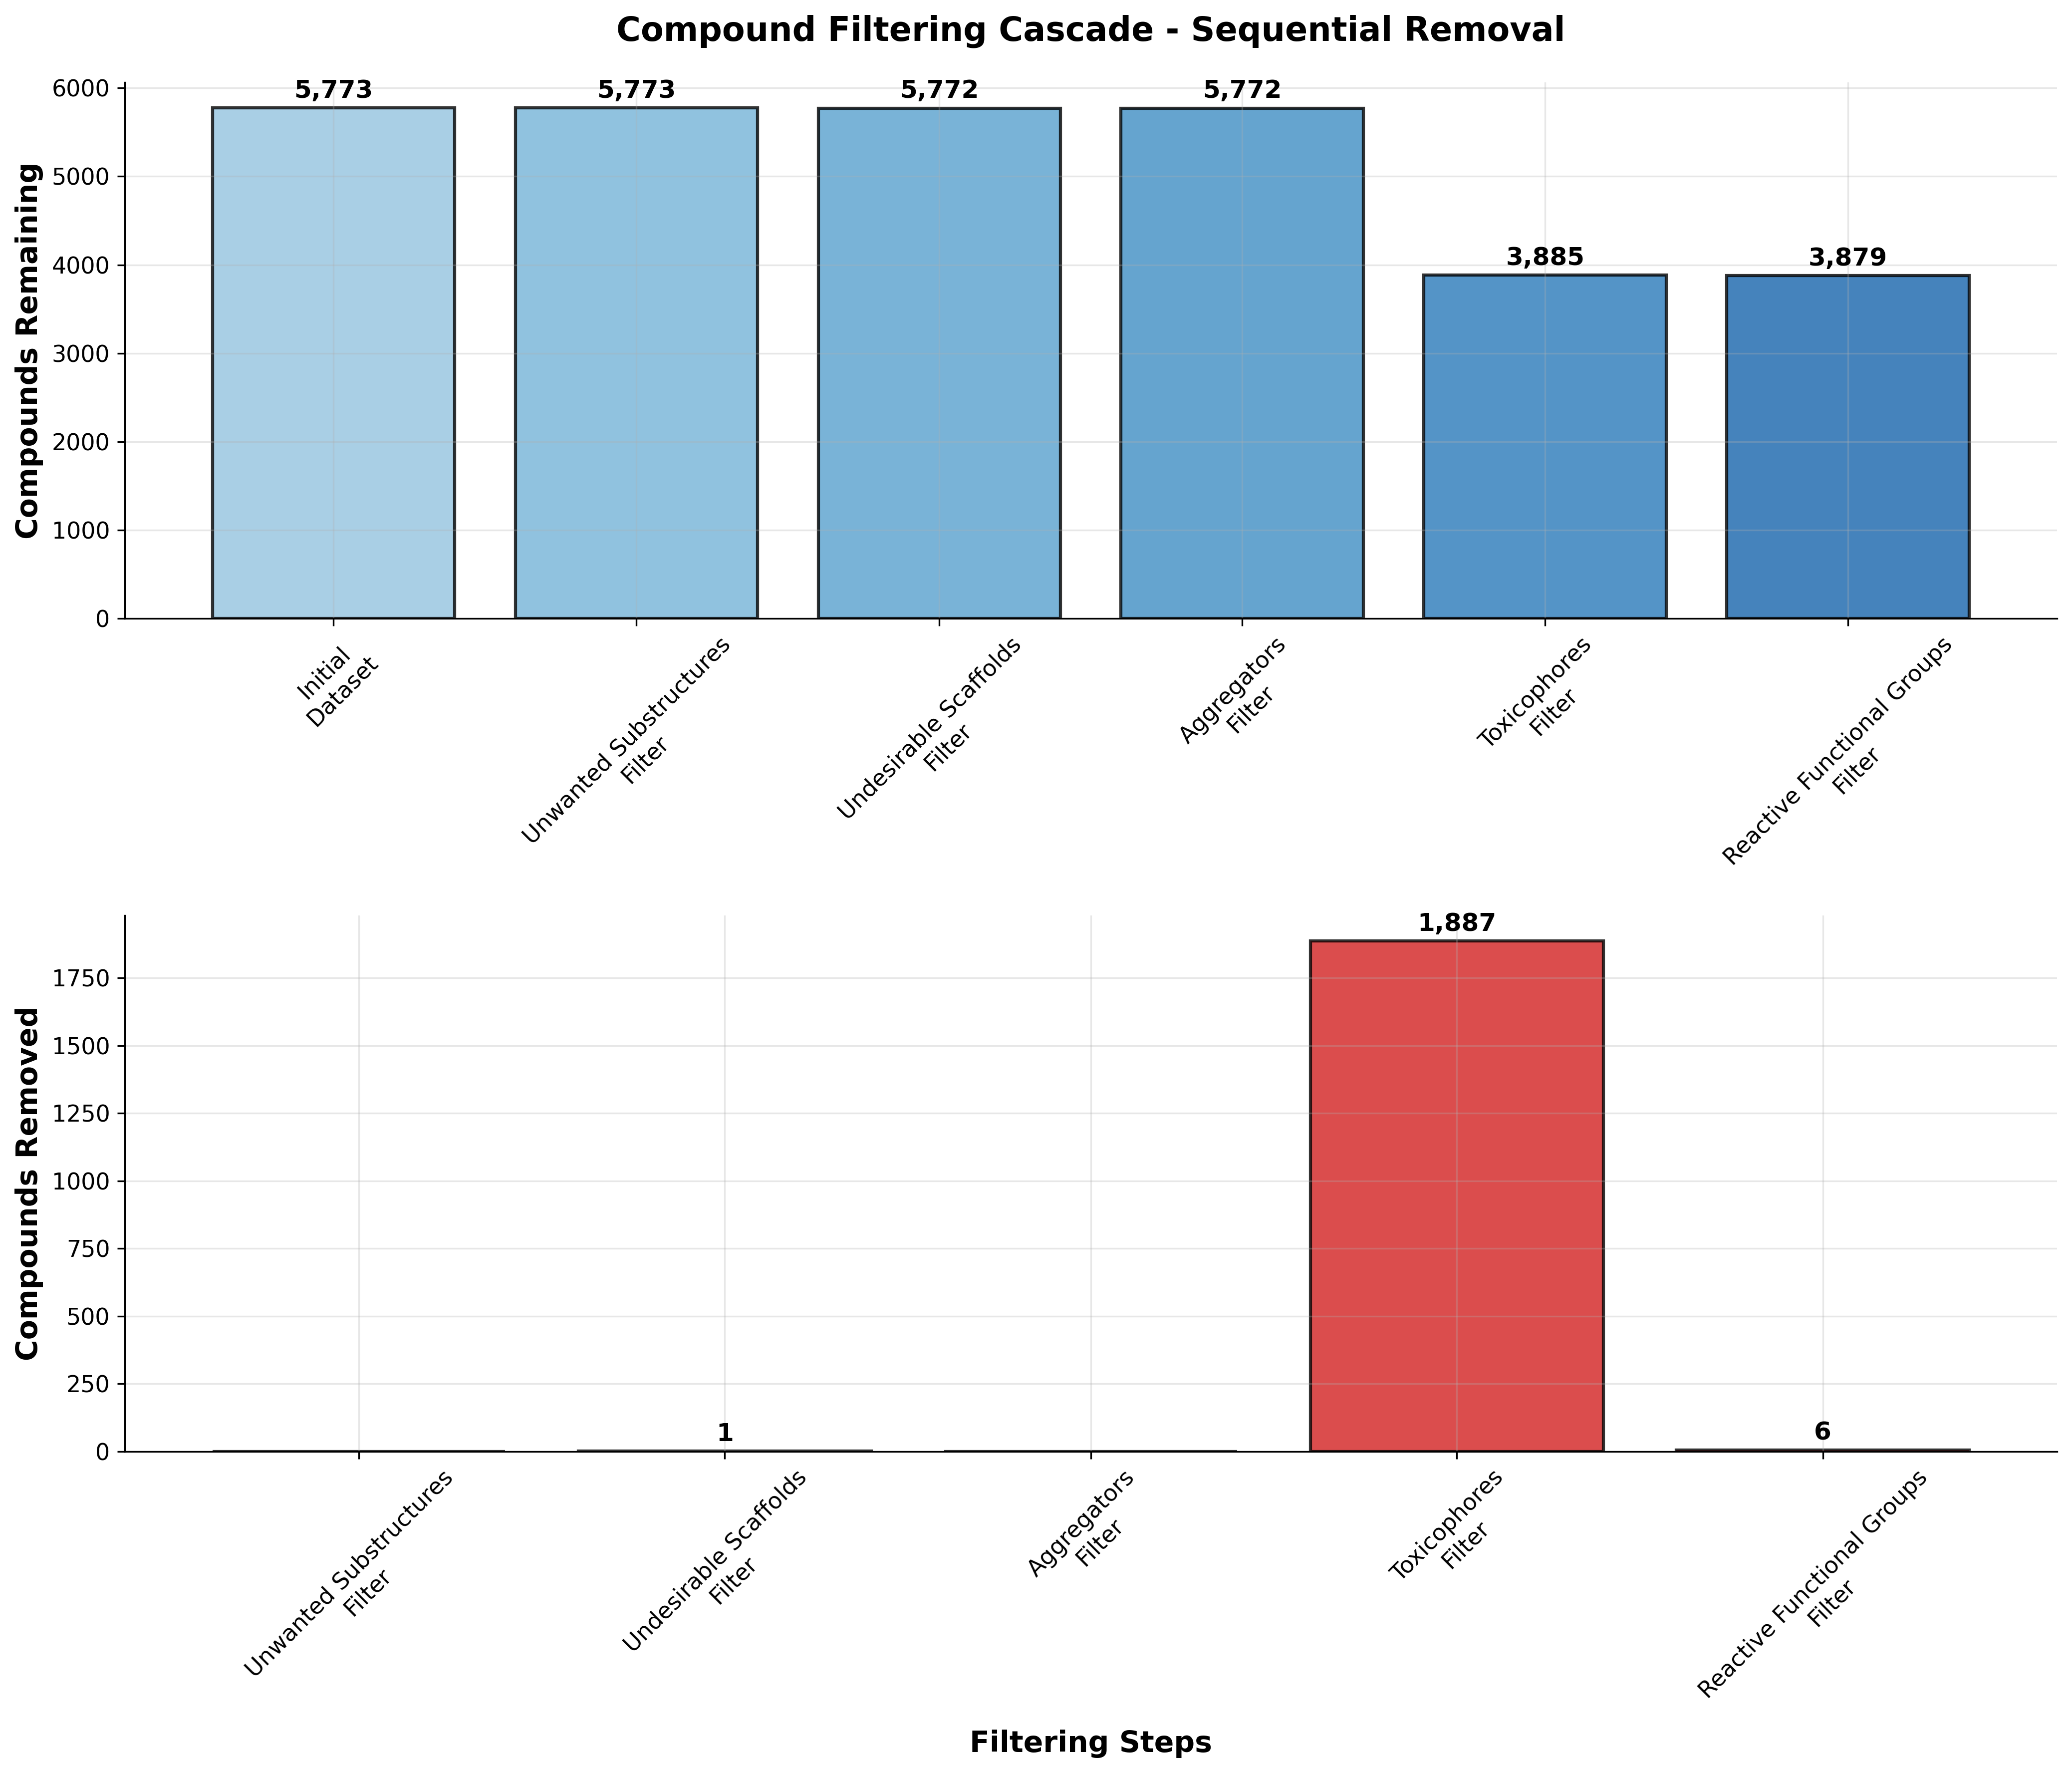

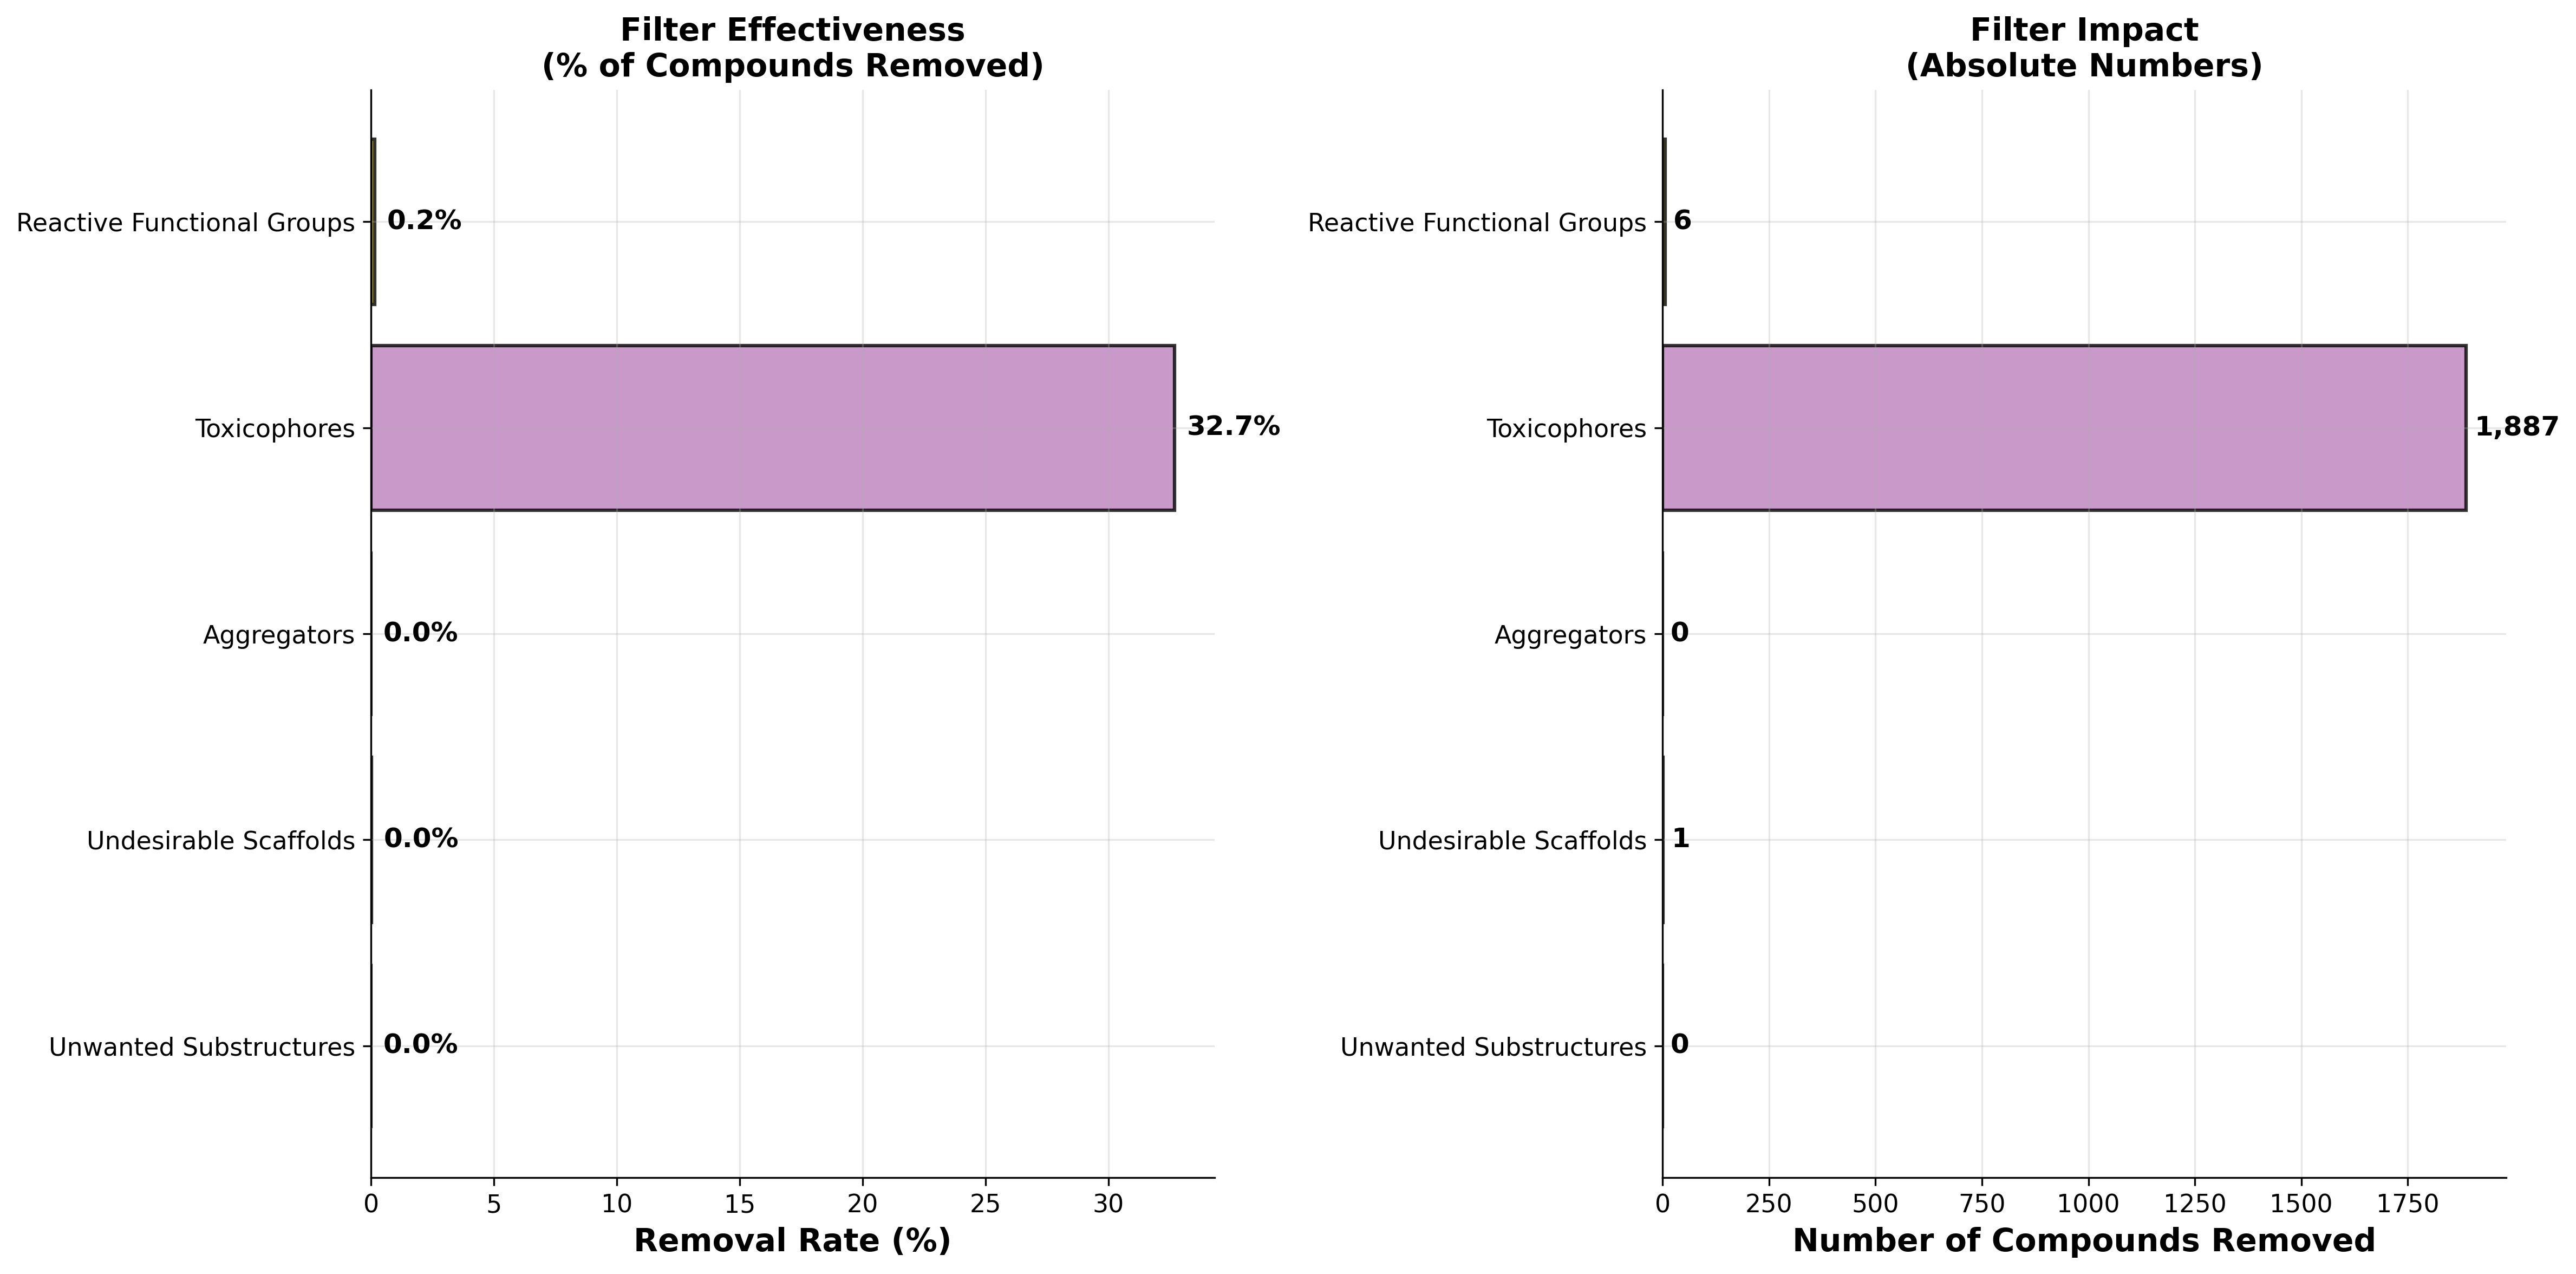

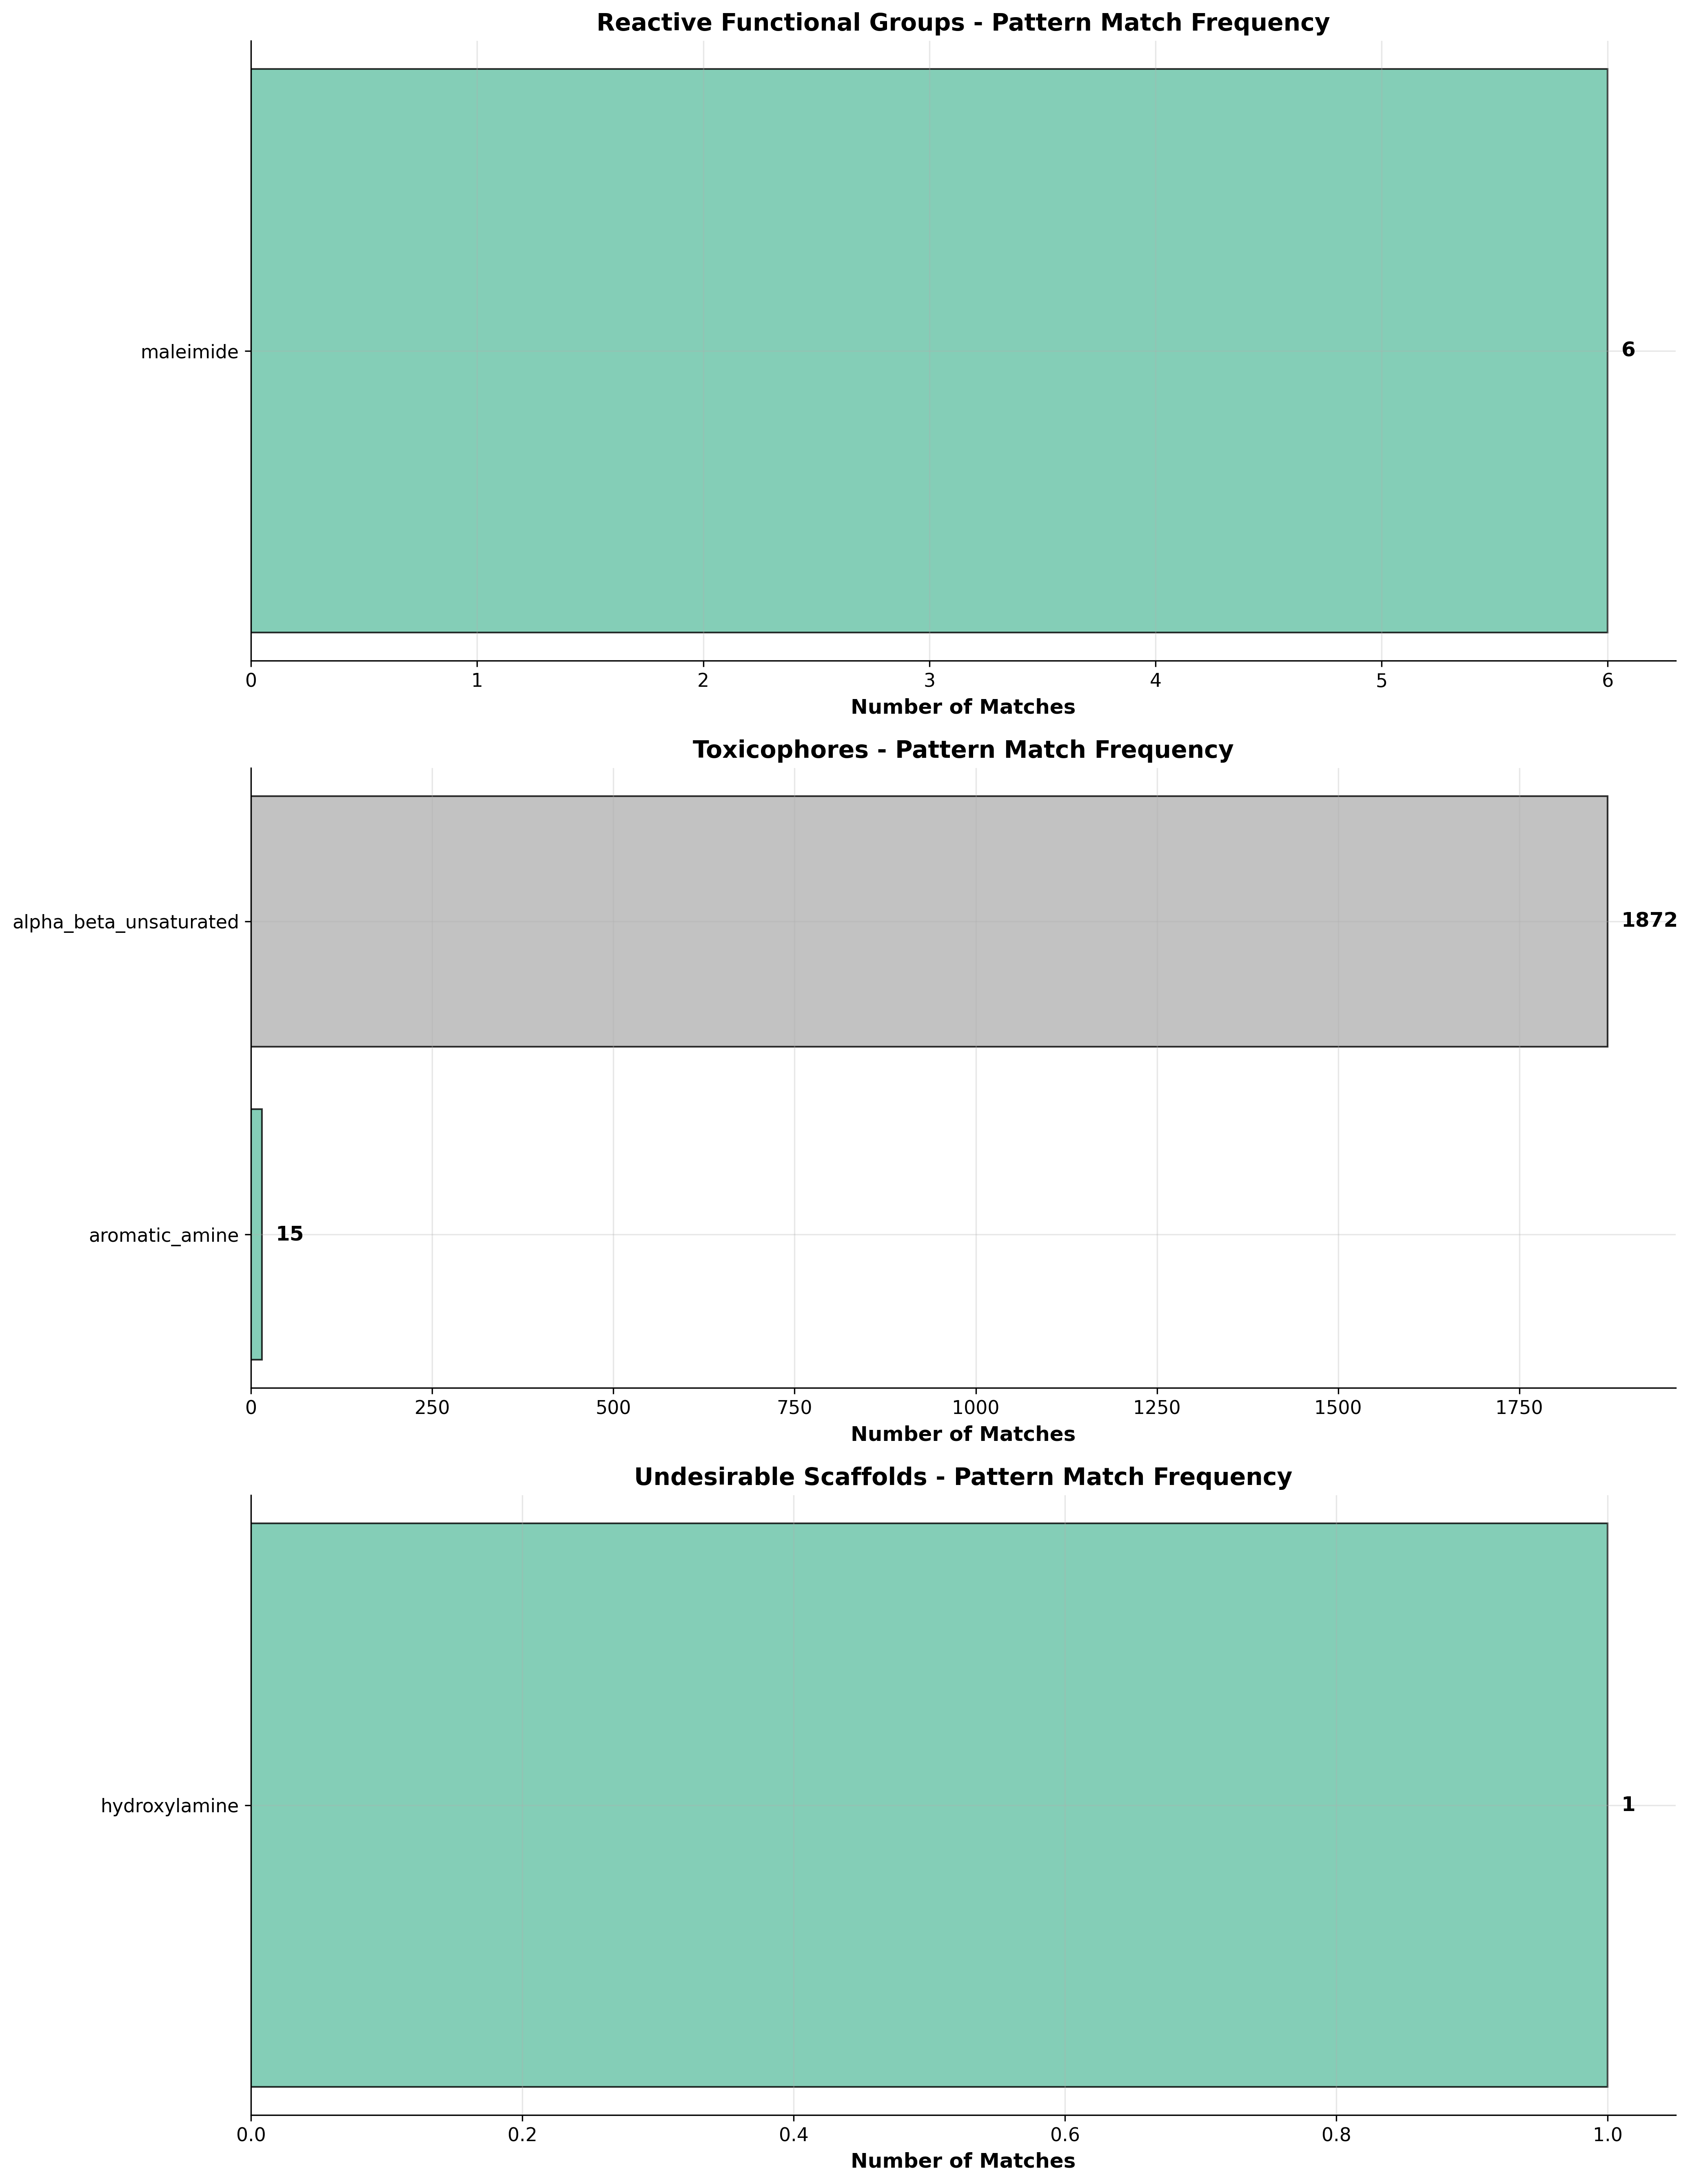

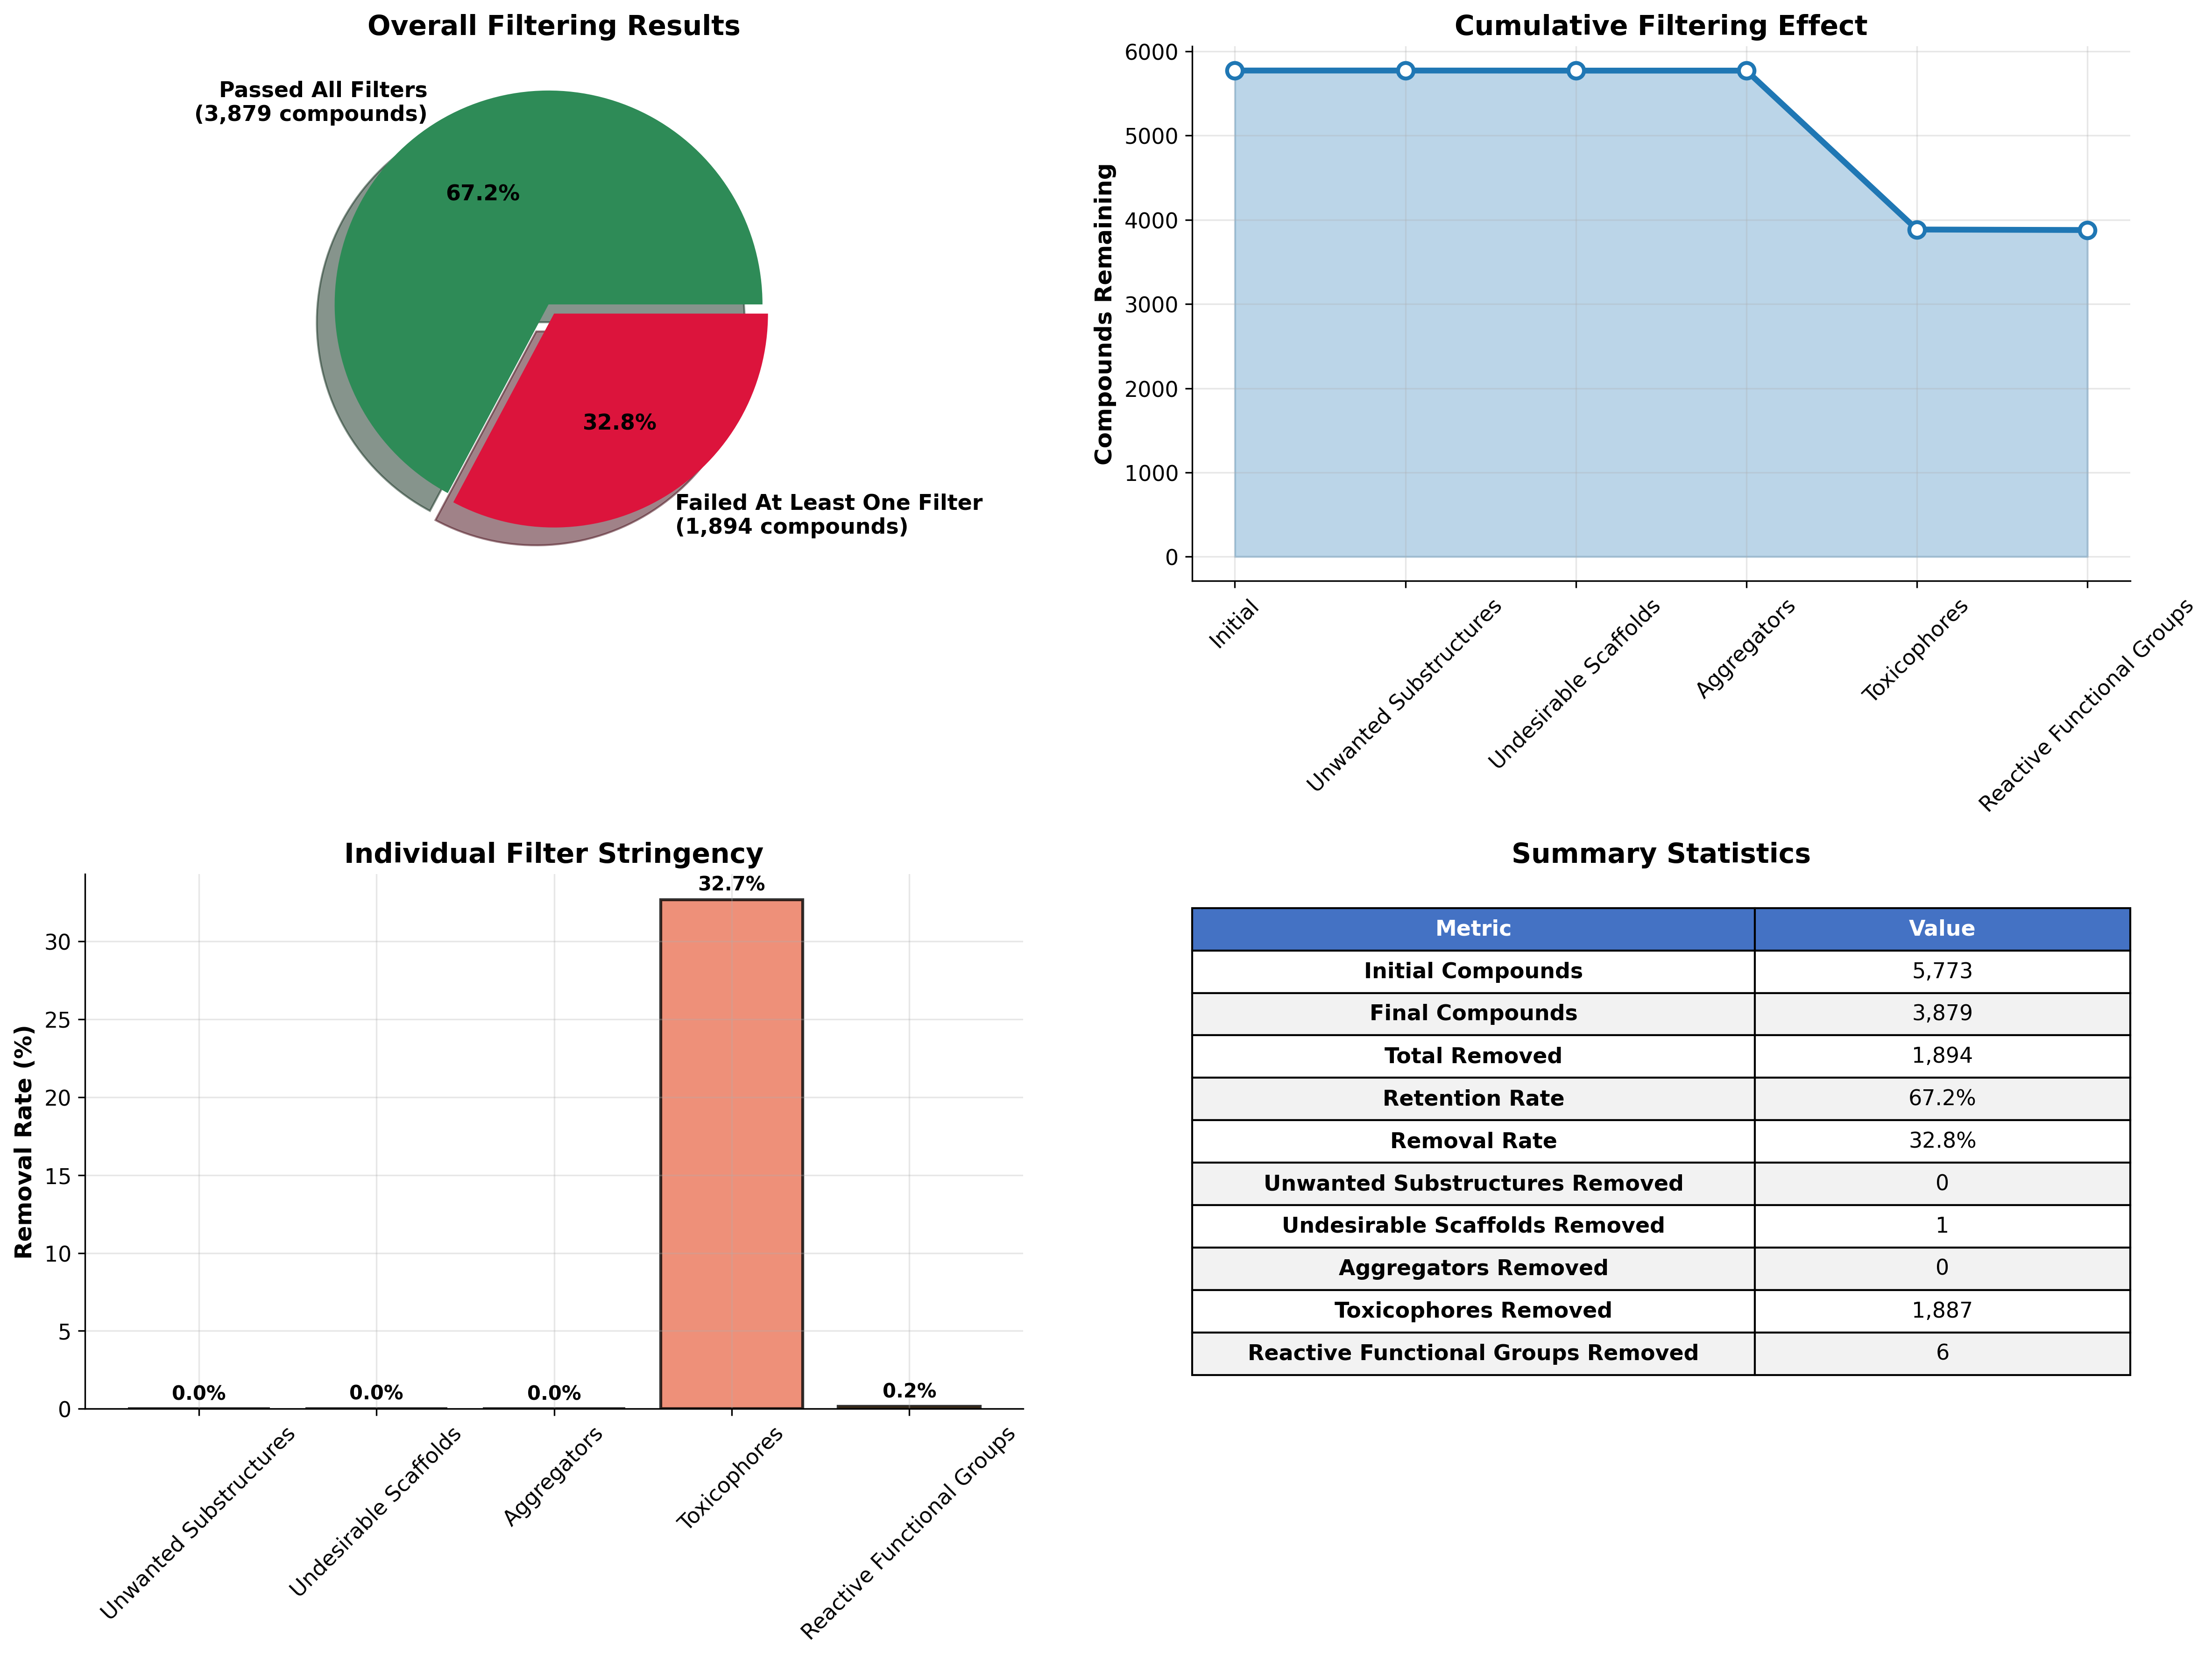

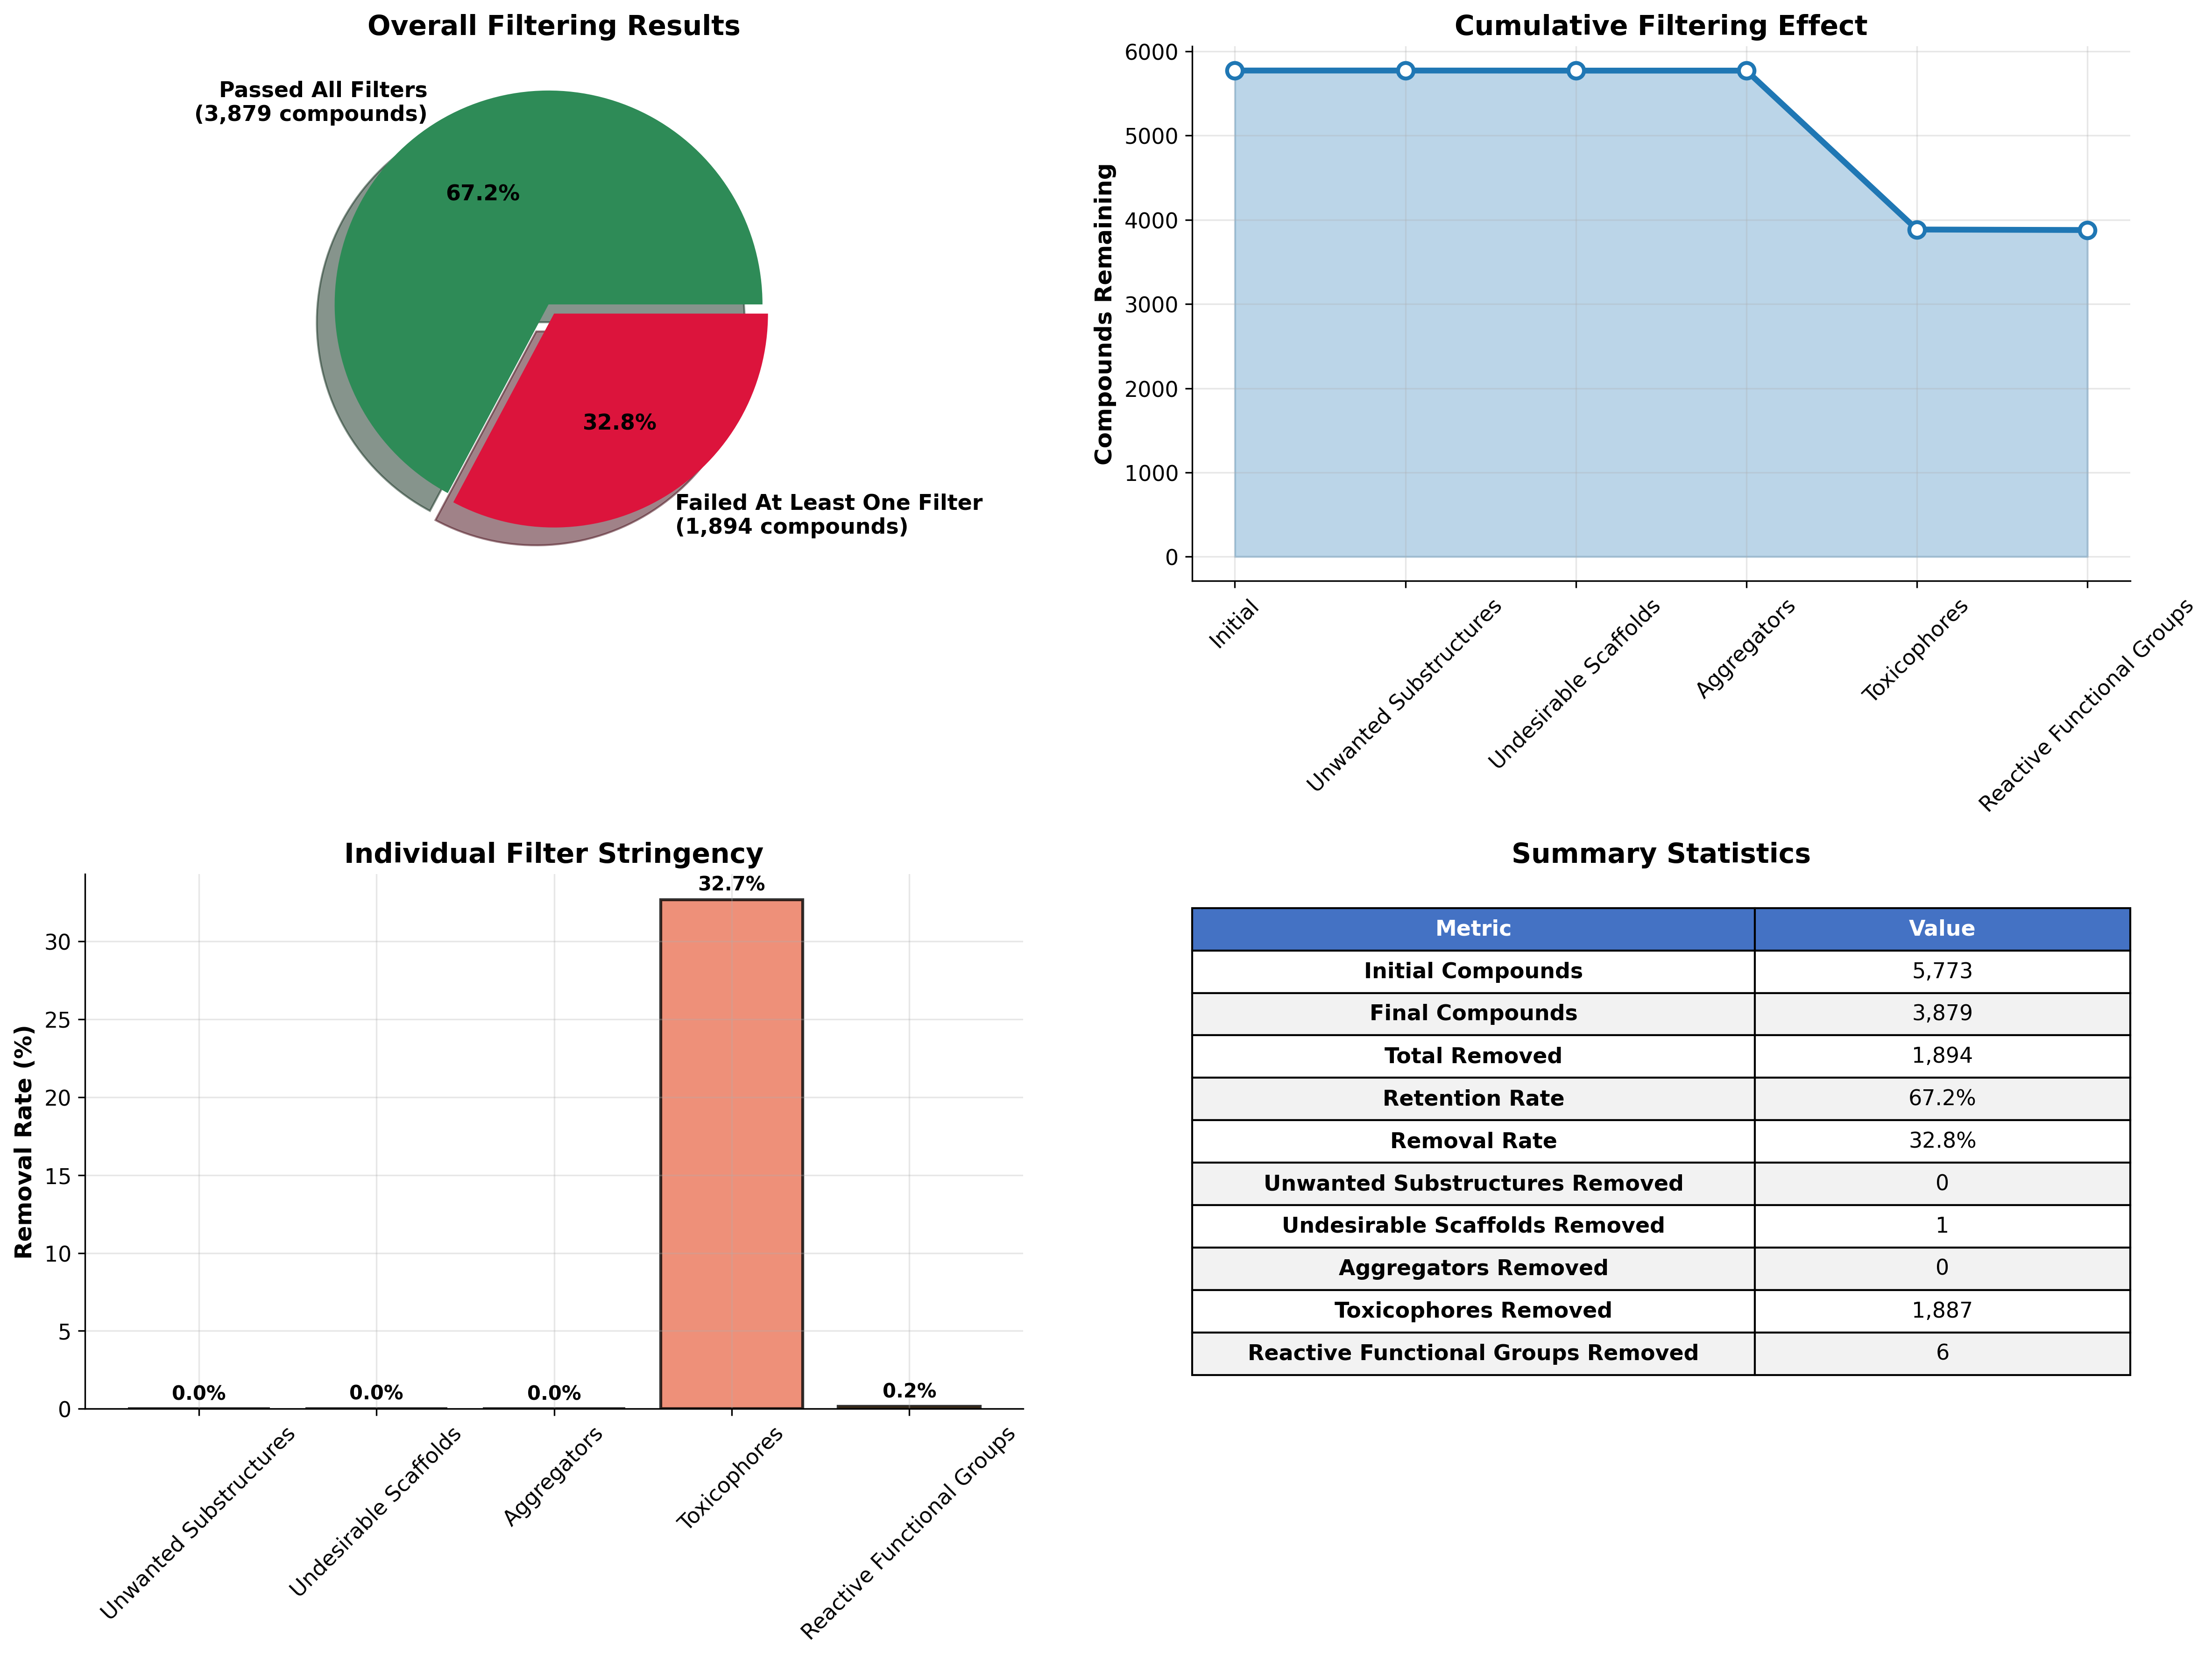

In [ ]:
# @title 11: Run Filtering Pipeline and Generate Visualizations
current_data = compounds_data.copy()
all_stats = []
all_matches = []

filter_definitions = [
    ("Unwanted Substructures", create_unwanted_substructures_from_df()),
    ("Undesirable Scaffolds", create_undesirable_scaffolds()),
    ("Aggregators", create_aggregators()),
    ("Toxicophores", create_toxicophores()),
    ("Reactive Functional Groups", create_reactive_groups())
]

for filter_name, patterns in filter_definitions:
    filtered_data, matches_df, stats = filter_compounds_by_patterns(
        current_data, patterns, filter_name
    )

    stats['filter_name'] = filter_name
    all_stats.append(stats)

    if not matches_df.empty:
        all_matches.append(matches_df)
        matches_df.to_csv(output_dir / f"{filter_name.lower().replace(' ', '_')}_matches.csv", index=False)

    current_data = filtered_data
    print(f"Compounds remaining after {filter_name}: {len(current_data)}")

print("Creating publication-quality plots...")
create_filtering_cascade_plot(all_stats, output_dir)
create_filter_summary_plot(all_stats, output_dir)
create_pattern_analysis_plot(all_matches, output_dir)
create_final_summary_plot(valid_count, len(current_data), all_stats, output_dir)


In [ ]:
# @title 12: Save Results and Prepare Download
final_data = current_data.copy()
if 'ROMol' in final_data.columns:
    final_data = final_data.drop('ROMol', axis=1)

final_output_file = output_dir / "final_filtered_compounds.csv"
final_data.to_csv(final_output_file, index=False)
print(f"Saved final filtered compounds to {final_output_file}")

summary_report = []
summary_report.append("="*80)
summary_report.append("FINAL REPORT")
summary_report.append("="*80)
summary_report.append(f"Initial compounds: {valid_count}")
summary_report.append(f"Final compounds: {len(final_data)}")
summary_report.append(f"Total removed: {valid_count - len(final_data)}")
summary_report.append("")

for stats in all_stats:
    summary_report.append(f"{stats['filter_name']} removed {stats['failed_filter']} compounds")

with open(output_dir / "filtering_report.txt", "w") as f:
    f.write("\n".join(summary_report))

print("\n".join(summary_report))

import shutil
shutil.copy(output_dir / "final_filtered_compounds.csv", "/content/final_filtered_compounds.csv")
shutil.copy(output_dir / "filtering_report.txt", "/content/filtering_report.txt")

print("Downloading final filtered compounds...")
files.download("/content/final_filtered_compounds.csv")

print("Downloading filtering report...")
files.download("/content/filtering_report.txt")


Saved final filtered compounds to /content/filtered_compounds/final_filtered_compounds.csv
FINAL REPORT
Initial compounds: 5773
Final compounds: 3879
Total removed: 1894

Unwanted Substructures removed 0 compounds
Undesirable Scaffolds removed 1 compounds
Aggregators removed 0 compounds
Toxicophores removed 1887 compounds
Reactive Functional Groups removed 6 compounds


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# @title 12: Save Results and Download ZIP
import shutil
from google.colab import files

# Save final filtered data CSV
final_data = current_data.copy()
if 'ROMol' in final_data.columns:
    final_data = final_data.drop('ROMol', axis=1)

final_output_file = output_dir / "final_filtered_compounds.csv"
final_data.to_csv(final_output_file, index=False)
print(f"Saved final filtered compounds to {final_output_file}")

# Save summary report text file
summary_report_file = output_dir / "filtering_report.txt"
with open(summary_report_file, 'w') as f:
    f.write('\n'.join(summary_report))

print(f"Saved summary report to {summary_report_file}")

# Prepare ZIP archive path
zip_path = '/content/filtered_compounds.zip'

# Create ZIP file containing everything in output_dir
shutil.make_archive(base_name=zip_path.replace('.zip',''), format='zip', root_dir=str(output_dir))

print(f"Created ZIP archive: {zip_path}")

# Provide download link
files.download(zip_path)


Saved final filtered compounds to /content/filtered_compounds/final_filtered_compounds.csv
Saved summary report to /content/filtered_compounds/filtering_report.txt
Created ZIP archive: /content/filtered_compounds.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>